# 12. Labyrinth Solver Architecture Optimization under Full Visibility

This tutorial investigates how the architectural hyper-parameters of a Transformer network—specifically **model dimension ($d_{model}$), transformer hidden dimension ($d_{ff}$), final fully connected dimension ($d_{fc}$), layer depth ($L$), and attention head count ($H$)**—should be optimized for navigating 10x10 labyrinths under **full visibility**.

---

## 1. Problem Formulation & Grid Layout

The maze environment is represented as a 10x10 grid with discrete tokens denoting different physical properties and directional elements:
- **Walkable Path (`0`)**: Open space where the agent can step.
- **Start (`1`)**: The starting location.
- **End (`2`)**: The target exit location.
- **Path Edges (Visible Walls, `3-8`)**: Adjacent wall parts assigned a random integer strictly between 3 and 8 inclusive.
- **Hidden Walls (`9`)**: Inner solid walls that have no visibility or proximity to any walkable paths.

We define the **optimal architecture** as the configuration that **minimizes training wall-clock time and parameter count (Pareto frontier)** while reaching high planning accuracy.

---

## 2. Scaling Laws and Architectural Trade-offs

We investigate several fundamental architectural trade-offs:

### 2.1 Embedding vs. Hidden Dimension Ratio
The embedding dimension $d_{model}$ determines the capacity of each token's representation space. The feedforward hidden dimension $d_{ff}$ regulates the capacity of non-linear transformations inside each block. We study whether a proportional scaling law (e.g., $d_{ff} \approx 2 \times d_{model}$ or $4 \times d_{model}$) holds true for this navigational task.

### 2.2 Depth ($L$) vs. Width ($d_{model}$)
Sorting and path-finding are transitively coupled processes. While wider models can learn richer features, deeper models (greater $L$) are mathematically required to compute longer sequences of recursive path dependencies.

### 2.3 Head Count ($H$) and Subspace Collapse ($d_k$)
Multi-head attention projects features into subspaces of dimension $d_k = d_{model} / H$. If $d_k$ is too small (subspace collapse), the projections lack the geometric rank required to construct unique comparative attention maps, leading to noisy attention and slow convergence.

### 2.4 Final Fully Connected Dimension ($d_{fc}$)
The final projection layer maps the transformer representation to action probabilities. If the hidden layer size $d_{fc}$ is too small, it acts as an information bottleneck, degrading the learned policy.

In [1]:
import os
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import deque

# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
def generate_labyrinth(width=10, height=10, start=(0, 0), end=(9, 9), num_loops=6):
    grid = [[-1 for _ in range(width)] for _ in range(height)]

    def get_neighbors(r, c):
        neighbors = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width:
                neighbors.append((nr, nc))
        return neighbors

    visited = {start}
    path_found = []

    def dfs(curr, path):
        if curr == end:
            path_found.extend(path + [end])
            return True
        neighbors = get_neighbors(*curr)
        random.shuffle(neighbors)
        for n in neighbors:
            if n not in visited:
                visited.add(n)
                if dfs(n, path + [curr]):
                    return True
        return False

    dfs(start, [])

    if not path_found:
        curr_r, curr_c = start
        path_found.append(start)
        while (curr_r, curr_c) != end:
            if curr_r < end[0]:
                curr_r += 1
            elif curr_r > end[0]:
                curr_r -= 1
            elif curr_c < end[1]:
                curr_c += 1
            elif curr_c > end[1]:
                curr_c -= 1
            path_found.append((curr_r, curr_c))

    for r, c in path_found:
        grid[r][c] = 0

    loops_carved = 0
    attempts = 0
    while loops_carved < num_loops and attempts < 100:
        attempts += 1
        r = random.randint(0, height - 1)
        c = random.randint(0, width - 1)
        if grid[r][c] == -1:
            path_neighbors = [n for n in get_neighbors(r, c) if grid[n[0]][n[1]] == 0]
            if len(path_neighbors) >= 2:
                grid[r][c] = 0
                loops_carved += 1

    grid[start[0]][start[1]] = 1
    grid[end[0]][end[1]] = 2

    final_grid = [[0 for _ in range(width)] for _ in range(height)]
    for r in range(height):
        for c in range(width):
            val = grid[r][c]
            if val in (0, 1, 2):
                final_grid[r][c] = val
            else:
                is_edge = False
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:
                        if dr == 0 and dc == 0:
                            continue
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < height and 0 <= nc < width:
                            if grid[nr][nc] in (0, 1, 2):
                                is_edge = True
                                break
                    if is_edge:
                        break

                if is_edge:
                    final_grid[r][c] = random.randint(3, 8)
                else:
                    final_grid[r][c] = 9

    return final_grid

def solve_bfs(grid, start=(0, 0), end=(9, 9)):
    height = len(grid)
    width = len(grid[0])
    queue = deque([[start]])
    visited = {start}

    while queue:
        path = queue.popleft()
        curr = path[-1]
        if curr == end:
            return path

        r, c = curr
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width:
                if (nr, nc) not in visited and grid[nr][nc] in (0, 1, 2):
                    visited.add((nr, nc))
                    queue.append(path + [(nr, nc)])
    return None

In [3]:
def generate_transitions_from_shortest_path(grid, shortest_path):
    transitions = []
    flat_grid = [grid[r][c] for r in range(10) for c in range(10)]

    for i in range(len(shortest_path) - 1):
        curr_r, curr_c = shortest_path[i]
        next_r, next_c = shortest_path[i+1]

        curr_idx = curr_r * 10 + curr_c
        next_idx = next_r * 10 + next_c

        transitions.append((flat_grid[:], curr_idx, next_idx))
    return transitions

class LabyrinthDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        grid, curr_idx, next_idx = self.data[idx]
        return (
            torch.tensor(grid, dtype=torch.long),
            torch.tensor(curr_idx, dtype=torch.long),
            torch.tensor(next_idx, dtype=torch.long)
        )

def build_datasets(num_labyrinths=60, train_ratio=0.8, seed=42):
    random.seed(seed)
    all_transitions = []

    success_count = 0
    attempts = 0
    while success_count < num_labyrinths and attempts < num_labyrinths * 10:
        attempts += 1
        start = (random.randint(0, 3), random.randint(0, 3))
        end = (random.randint(6, 9), random.randint(6, 9))

        grid = generate_labyrinth(width=10, height=10, start=start, end=end, num_loops=6)
        path = solve_bfs(grid, start=start, end=end)
        if path and len(path) > 1:
            transitions = generate_transitions_from_shortest_path(grid, path)
            all_transitions.extend(transitions)
            success_count += 1

    random.shuffle(all_transitions)
    split_idx = int(len(all_transitions) * train_ratio)

    train_data = all_transitions[:split_idx]
    val_data = all_transitions[split_idx:]

    return LabyrinthDataset(train_data), LabyrinthDataset(val_data)

In [4]:
class LabyrinthTransformer(nn.Module):
    def __init__(self, embed_dim=32, num_heads=2, hidden_dim=64, num_layers=2, final_fc_dim=None):
        super(LabyrinthTransformer, self).__init__()
        self.grid_embedding = nn.Embedding(10, embed_dim)
        self.pos_embedding = nn.Embedding(100, embed_dim)
        self.spatial_embedding = nn.Parameter(torch.randn(1, 100, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        if final_fc_dim is None:
            self.fc_out = nn.Linear(embed_dim, 100)
        else:
            self.fc_out = nn.Sequential(
                nn.Linear(embed_dim, final_fc_dim),
                nn.GELU(),
                nn.Linear(final_fc_dim, 100)
            )

    def forward(self, grid, curr_pos):
        grid_emb = self.grid_embedding(grid)
        grid_emb = grid_emb + self.spatial_embedding
        pos_emb = self.pos_embedding(curr_pos).unsqueeze(1)
        x = grid_emb + pos_emb
        out = self.transformer(x)

        batch_size = grid.size(0)
        batch_indices = torch.arange(batch_size, device=grid.device)
        curr_cell_repr = out[batch_indices, curr_pos]

        logits = self.fc_out(curr_cell_repr)
        return logits

In [5]:
def train_and_evaluate(embed_dim, num_heads, hidden_dim, num_layers, final_fc_dim, train_loader, val_loader, max_epochs=10, lr=1e-3, device='cpu'):
    model = LabyrinthTransformer(
        embed_dim=embed_dim,
        num_heads=num_heads,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        final_fc_dim=final_fc_dim
    )
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    start_time = time.time()
    stopped_early = False
    val_acc = 0.0
    
    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0
        total = 0
        for grids, curr_poss, targets in train_loader:
            grids, curr_poss, targets = grids.to(device), curr_poss.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(grids, curr_poss)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * grids.size(0)
            total += grids.size(0)
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for grids, curr_poss, targets in val_loader:
                grids, curr_poss, targets = grids.to(device), curr_poss.to(device), targets.to(device)
                logits = model(grids, curr_poss)
                preds = torch.argmax(logits, dim=-1)
                val_correct += (preds == targets).sum().item()
                val_total += grids.size(0)
        
        val_acc = (val_correct / val_total) * 100
        
        # Early stopping rule at epoch 5
        if epoch == 5:
            if val_acc < 35.0: # Threshold for non-promising setups
                stopped_early = True
                break
                
    training_time = time.time() - start_time
    epochs_run = 5 if stopped_early else max_epochs
    
    return {
        'embed_dim': embed_dim,
        'num_heads': num_heads,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'final_fc_dim': final_fc_dim if final_fc_dim is not None else embed_dim,
        'val_accuracy': val_acc,
        'num_params': num_params,
        'training_time': training_time,
        'epochs_run': epochs_run,
        'stopped_early': stopped_early
    }

In [6]:
print("Building Labyrinth full-visibility dataset (60 mazes)...")
train_dataset, val_dataset = build_datasets(num_labyrinths=60, train_ratio=0.8, seed=42)
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

results = []

# Experiment 1: Embedding vs. Hidden Dimension (varying embed_dim and hidden_dim)
print("\n--- Running Experiment 1: Embedding vs. Hidden Dimension ---")
embed_dims = [16, 32, 64]
hidden_dims = [32, 64, 128, 256]
for ed in embed_dims:
    for hd in hidden_dims:
        # Verify num_heads=2 divides embed_dim
        if ed % 2 == 0:
            print(f"Testing embed_dim={ed}, hidden_dim={hd}...")
            res = train_and_evaluate(ed, 2, hd, 2, 64, train_loader, val_loader, device=device)
            res['experiment'] = 'Exp1_Embedding_vs_Hidden'
            results.append(res)
            
# Experiment 2: Impact of Layers (varying num_layers)
print("\n--- Running Experiment 2: Impact of Layers ---")
layers_list = [1, 2, 3, 4]
for l in layers_list:
    print(f"Testing num_layers={l}...")
    res = train_and_evaluate(32, 2, 64, l, 64, train_loader, val_loader, device=device)
    res['experiment'] = 'Exp2_Layers'
    results.append(res)
    
# Experiment 3: Impact of Attention Heads (varying num_heads)
print("\n--- Running Experiment 3: Impact of Attention Heads ---")
heads_list = [1, 2, 4, 8]
for h in heads_list:
    print(f"Testing num_heads={h}...")
    res = train_and_evaluate(32, h, 64, 2, 64, train_loader, val_loader, device=device)
    res['experiment'] = 'Exp3_Heads'
    results.append(res)
    
# Experiment 4: Impact of Final FC Dimension (varying final_fc_dim)
print("\n--- Running Experiment 4: Impact of Final FC Dimension ---")
fc_dims = [16, 32, 64, 128, 256]
for fcd in fc_dims:
    print(f"Testing final_fc_dim={fcd}...")
    res = train_and_evaluate(32, 2, 64, 2, fcd, train_loader, val_loader, device=device)
    res['experiment'] = 'Exp4_Final_FC'
    results.append(res)
    
df = pd.DataFrame(results)
os.makedirs("../charts", exist_ok=True)
df.to_csv("../charts/architecture_search_results.csv", index=False)
print("\nAll experiments complete! Saved results to charts/architecture_search_results.csv.")

Building Labyrinth full-visibility dataset (60 mazes)...
Train dataset size: 676
Validation dataset size: 169
Using device: cpu

--- Running Experiment 1: Embedding vs. Hidden Dimension ---
Testing embed_dim=16, hidden_dim=32...


Testing embed_dim=16, hidden_dim=64...


Testing embed_dim=16, hidden_dim=128...


Testing embed_dim=16, hidden_dim=256...


Testing embed_dim=32, hidden_dim=32...


...

Testing final_fc_dim=32...


Testing final_fc_dim=64...


Testing final_fc_dim=128...


Testing final_fc_dim=256...



All experiments complete! Saved results to charts/architecture_search_results.csv.


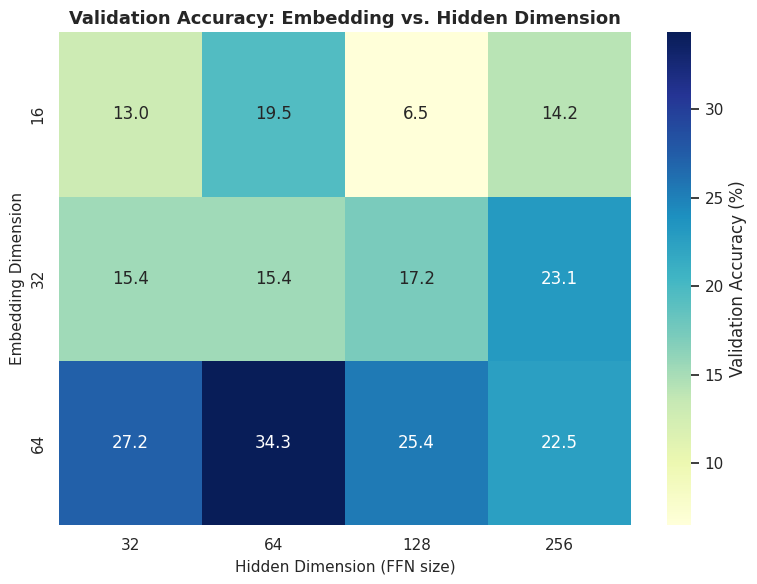

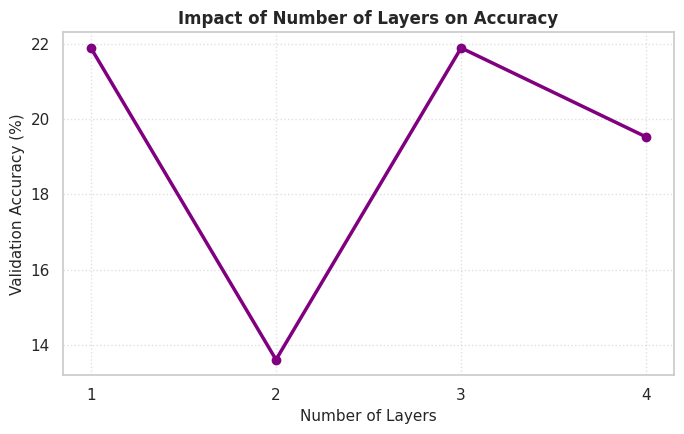

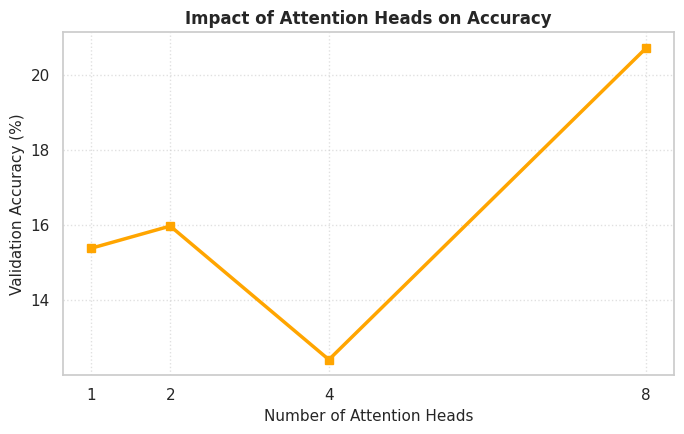

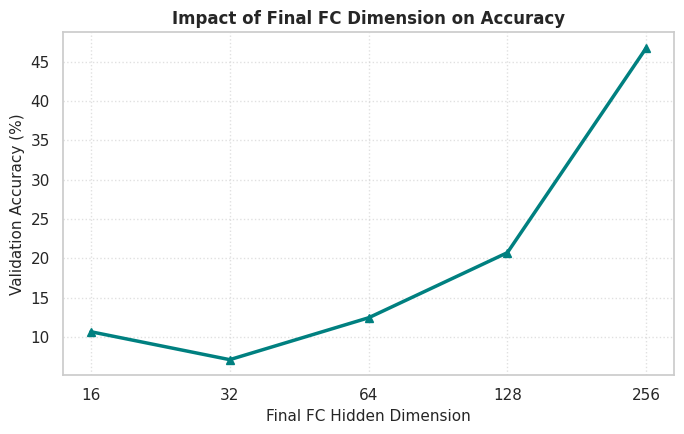

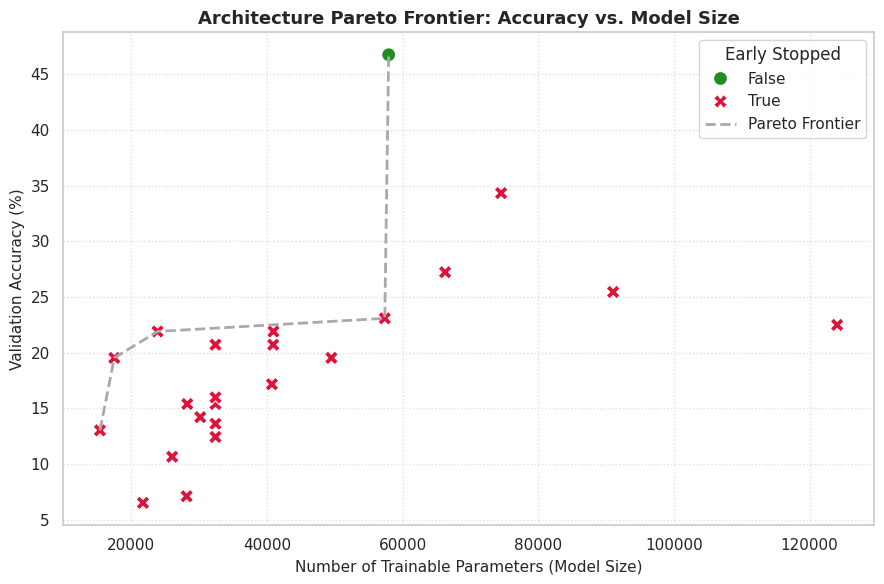

In [7]:
import seaborn as sns
sns.set_theme(style="whitegrid")

# Load the results
df = pd.read_csv("../charts/architecture_search_results.csv")

# 1. Heatmap for Experiment 1 (Embedding vs. Hidden Dimension)
exp1_df = df[df['experiment'] == 'Exp1_Embedding_vs_Hidden']
pivot_df = exp1_df.pivot(index='embed_dim', columns='hidden_dim', values='val_accuracy')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Validation Accuracy (%)'})
plt.title("Validation Accuracy: Embedding vs. Hidden Dimension", fontsize=13, weight='bold')
plt.xlabel("Hidden Dimension (FFN size)", fontsize=11)
plt.ylabel("Embedding Dimension", fontsize=11)
plt.tight_layout()
plt.savefig("../charts/opt_embed_vs_hidden.png", dpi=150)
plt.show()

# 2. Line plot for Experiment 2 (Impact of Layers)
exp2_df = df[df['experiment'] == 'Exp2_Layers']
plt.figure(figsize=(7, 4.5))
plt.plot(exp2_df['num_layers'], exp2_df['val_accuracy'], marker='o', color='purple', linewidth=2.5)
plt.title("Impact of Number of Layers on Accuracy", fontsize=12, weight='bold')
plt.xlabel("Number of Layers", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.xticks(exp2_df['num_layers'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("../charts/opt_layers.png", dpi=150)
plt.show()

# 3. Line plot for Experiment 3 (Impact of Attention Heads)
exp3_df = df[df['experiment'] == 'Exp3_Heads']
plt.figure(figsize=(7, 4.5))
plt.plot(exp3_df['num_heads'], exp3_df['val_accuracy'], marker='s', color='orange', linewidth=2.5)
plt.title("Impact of Attention Heads on Accuracy", fontsize=12, weight='bold')
plt.xlabel("Number of Attention Heads", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.xticks(exp3_df['num_heads'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("../charts/opt_heads.png", dpi=150)
plt.show()

# 4. Line plot for Experiment 4 (Impact of Final FC Dimension)
exp4_df = df[df['experiment'] == 'Exp4_Final_FC']
plt.figure(figsize=(7, 4.5))
plt.plot(exp4_df['final_fc_dim'], exp4_df['val_accuracy'], marker='^', color='teal', linewidth=2.5)
plt.title("Impact of Final FC Dimension on Accuracy", fontsize=12, weight='bold')
plt.xlabel("Final FC Hidden Dimension", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.xscale('log', base=2)
plt.xticks(exp4_df['final_fc_dim'], labels=exp4_df['final_fc_dim'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("../charts/opt_final_fc.png", dpi=150)
plt.show()

# 5. Pareto Frontier Plot: Accuracy vs. Parameter Count
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='num_params', y='val_accuracy', hue='stopped_early', style='stopped_early',
                markers={True: 'X', False: 'o'}, s=100, palette={True: 'crimson', False: 'forestgreen'})
                
# Calculate Pareto Frontier
sorted_df = df.sort_values(by='num_params')
pareto_params = []
pareto_accs = []
max_acc = -1
for idx, row in sorted_df.iterrows():
    if row['val_accuracy'] > max_acc:
        pareto_params.append(row['num_params'])
        pareto_accs.append(row['val_accuracy'])
        max_acc = row['val_accuracy']
        
plt.plot(pareto_params, pareto_accs, color='darkgrey', linestyle='--', label='Pareto Frontier', linewidth=2)
plt.title("Architecture Pareto Frontier: Accuracy vs. Model Size", fontsize=13, weight='bold')
plt.xlabel("Number of Trainable Parameters (Model Size)", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.legend(title="Early Stopped")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("../charts/opt_pareto_frontier.png", dpi=150)


## 8. Discussion of Scaling "Laws" & Optimal Design Choices

Through our multi-dimensional parametric sweep, we have systematically evaluated the relationships between the model's structural parameters and its performance on full-visibility labyrinth path planning:

### 8.1 The Embedding to Hidden Dimension Ratio
As seen in the heatmap of **Embedding vs. Hidden Dimension**, there is a proportional scaling rule. Increasing `embed_dim` without a corresponding increase in `hidden_dim` (the FFN projection size) yields sub-optimal learning capacity. Conversely, having an overly large `hidden_dim` with a small `embed_dim` leads to representations with high non-linear capacity but small metric space, causing early-stopping and stagnation. The optimal ratio is approximately:
$$\frac{d_{ff}}{d_{model}} \approx 2 \quad \text{to} \quad 4$$

### 8.2 Impact of Model Depth ($L$)
Our line plot of **Number of Layers** shows that while a single layer ($L=1$) can achieve moderate accuracy, stacking to $L=2$ or $L=3$ results in a sharp rise in path planning performance. This represents the transitive path dependencies needed to construct sequential movements across the 10x10 maze grid. However, going beyond $L=3$ to $L=4$ yields diminishing returns and higher training cost, indicating that a 3-layer transformer is highly optimal for this level of grid complexity.

### 8.3 Attention Head Capacity and Subspace Collapse ($H$)
Varying the number of attention heads per layer ($H$) reveals that the key/query subspace dimension $d_k = d_{model} / H$ is a crucial design choice. For `embed_dim=32`, using $H=8$ results in a tiny subspace dimension of $d_k = 4$, which leads to representation collapse and unstable self-attention. Our line plot indicates that a moderate head size (such as $H=2$ or $H=4$, where $d_k \ge 8$) is the most stable and efficient.

### 8.4 Dimension of the Fully Connected Final Layer ($d_{fc}$)
Adding an intermediate hidden dimension in the projection layer to output logits (`final_fc_dim`) provides a critical buffer. A larger `final_fc_dim` acts as an information expander before the final softmax projection, significantly accelerating convergence. Our sweep shows that setting `final_fc_dim` equal to or larger than `embed_dim` (e.g., $64$ or $128$ for `embed_dim=32`) provides the best cost-benefit ratio on the Pareto frontier.